# Three Marginal Ordinal Regressions with Shared Imputation

This notebook implements a Bayesian model that combines:
1. **Three marginal ordinal outcome models** (LIFENOW, SATJOB, SATFIN) — fitted independently (no residual correlation structure)
2. **Four predictors with missing data** (hlthdep, stress, wrkmeangfl, anxiety) modeled as correlated latent variables
3. **Shared imputation** — all three outcome models use the same imputed latent predictor values

## Rationale for Marginal Models

The bivariate_ordinal_regression.ipynb analysis showed that residual correlations between outcomes are small after accounting for predictors:
- ρ(LIFENOW, SATJOB): -0.063 (94% HDI includes zero)
- ρ(LIFENOW, SATFIN): -0.179 (94% HDI includes zero)
- ρ(SATJOB, SATFIN): 0.099 (94% HDI includes zero)

Given the minimal benefit from joint modeling and the added complexity, marginal models are preferred.

## Model Architecture

### Layer 1: Latent Predictor Model (Shared Imputation)
The 4 predictors with missing data share a correlated latent structure:
$$
\mathbf{z}_i = [z_{\text{hlthdep}}, z_{\text{stress}}, z_{\text{wrk}}, z_{\text{anxiety}}]_i \sim \text{MVN}(\boldsymbol{\mu}, \Sigma)
$$

### Layer 2: Predictor Observation Models
- **Ordinal predictors** (hlthdep, stress, wrkmeangfl): OrderedProbit linking $z$ to observed categories
- **Continuous predictor** (anxiety): Normal observation model

### Layer 3: Three Marginal Outcome Models
Three **independent** ordinal regression models using shared latent z + complete predictors:
$$
\eta_{\text{outcome}} = \mathbf{z} \cdot \boldsymbol{\beta}_{\text{outcome}} + \mathbf{X}_{\text{complete}} \cdot \boldsymbol{\gamma}_{\text{outcome}}
$$

## Setup

In [1]:
import pandas as pd
import numpy as np
import pymc as pm
import pytensor.tensor as pt
import arviz as az
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from scipy import stats
from pathlib import Path

np.random.seed(42)
pd.set_option('display.max_columns', None)

print(f'PyMC version: {pm.__version__}')
print(f'ArviZ version: {az.__version__}')

PyMC version: 5.27.0
ArviZ version: 0.22.0


## Data Loading

In [2]:
# Load data
df = pd.read_csv('../data/gss_2022.csv')
print(f'Full dataset: {df.shape}')
print(f'Columns: {list(df.columns)}')

Full dataset: (3544, 24)
Columns: ['year', 'id', 'age', 'sex', 'race', 'degree', 'satjob', 'hlthdep', 'stress', 'feelnerv', 'worry', 'wrkmeangfl', 'richwork', 'satfin', 'finrela', 'lifenow', 'wrkstat', 'hrs1', 'hrs2', 'spocc10', 'spind10', 'occ10', 'realrinc', 'anxiety']


In [3]:
# Define variable groups per the specification
outcomes = ['lifenow', 'satjob', 'satfin']

# Predictors with missing data (will be imputed)
predictors_to_impute = ['hlthdep', 'stress', 'wrkmeangfl', 'anxiety']

# Complete predictors (no missing data required)
complete_predictors = ['age', 'sex', 'degree', 'finrela']

all_vars = outcomes + predictors_to_impute + complete_predictors
print(f'Variables needed: {all_vars}')

Variables needed: ['lifenow', 'satjob', 'satfin', 'hlthdep', 'stress', 'wrkmeangfl', 'anxiety', 'age', 'sex', 'degree', 'finrela']


## Data Exploration: Missingness Patterns

In [4]:
# Analyze missingness for all variables
missing_stats = pd.DataFrame({
    'Variable': all_vars,
    'N_Total': [len(df) for _ in all_vars],
    'N_Missing': [df[v].isna().sum() for v in all_vars],
    'Pct_Missing': [100 * df[v].isna().mean() for v in all_vars]
})
missing_stats['Category'] = (
    ['Outcome'] * len(outcomes) + 
    ['Imputed Predictor'] * len(predictors_to_impute) + 
    ['Complete Predictor'] * len(complete_predictors)
)
print('=== MISSINGNESS SUMMARY ===')
print(missing_stats.to_string(index=False))

=== MISSINGNESS SUMMARY ===
  Variable  N_Total  N_Missing  Pct_Missing           Category
   lifenow     3544       1764    49.774266            Outcome
    satjob     3544       1081    30.502257            Outcome
    satfin     3544         18     0.507901            Outcome
   hlthdep     3544       2417    68.199774  Imputed Predictor
    stress     3544       1591    44.892777  Imputed Predictor
wrkmeangfl     3544       1591    44.892777  Imputed Predictor
   anxiety     3544       1596    45.033860  Imputed Predictor
       age     3544        208     5.869074 Complete Predictor
       sex     3544         20     0.564334 Complete Predictor
    degree     3544          0     0.000000 Complete Predictor
   finrela     3544         44     1.241535 Complete Predictor


In [5]:
# Visualize missingness patterns
fig = px.bar(
    missing_stats, 
    x='Variable', 
    y='Pct_Missing', 
    color='Category',
    title='Missingness by Variable',
    labels={'Pct_Missing': '% Missing'}
)
fig.update_layout(height=400, width=800)
fig.show()

In [6]:
# Outcome distributions (before filtering)
print('=== OUTCOME DISTRIBUTIONS (Raw) ===')
for var in outcomes:
    print(f'\n{var.upper()}:')
    print(df[var].value_counts().sort_index())

=== OUTCOME DISTRIBUTIONS (Raw) ===

LIFENOW:
lifenow
1.0       5
2.0       3
3.0      12
4.0      32
5.0      89
6.0     191
7.0     232
8.0     512
9.0     495
10.0    209
Name: count, dtype: int64

SATJOB:
satjob
1.0    1103
2.0    1012
3.0     241
4.0     107
Name: count, dtype: int64

SATFIN:
satfin
1.0     877
2.0    1568
3.0    1081
Name: count, dtype: int64


In [7]:
# Predictor distributions (for those to be imputed)
print('=== PREDICTOR DISTRIBUTIONS (Observed Values Only) ===')
for var in predictors_to_impute:
    print(f'\n{var.upper()}:')
    if var == 'anxiety':  # Continuous
        print(df[var].describe())
    else:  # Ordinal
        print(df[var].value_counts().sort_index())

=== PREDICTOR DISTRIBUTIONS (Observed Values Only) ===

HLTHDEP:
hlthdep
1.0    386
2.0    310
3.0    270
4.0     91
5.0     70
Name: count, dtype: int64

STRESS:
stress
1.0    171
2.0    409
3.0    906
4.0    339
5.0    128
Name: count, dtype: int64

WRKMEANGFL:
wrkmeangfl
1.0     680
2.0    1034
3.0     186
4.0      53
Name: count, dtype: int64

ANXIETY:
count    1948.000000
mean        1.673511
std         0.822873
min         1.000000
25%         1.000000
50%         1.500000
75%         2.000000
max         4.000000
Name: anxiety, dtype: float64


## Data Preparation

We filter to observations that have:
- Valid outcome values for all 3 outcomes
- Complete data for the complete predictors (age, sex, degree, finrela)
- May have missing data for the predictors to be imputed

In [8]:
# Start with full dataset, filter step by step
df_work = df.copy()

# Step 1: Valid outcomes
df_work = df_work[
    (df_work['lifenow'].between(1, 10)) & 
    (df_work['satjob'].between(1, 4)) &
    (df_work['satfin'].between(1, 3))
].copy()
print(f'After valid outcomes: {len(df_work)}')

# Step 2: Complete predictors must be non-missing
df_work = df_work.dropna(subset=complete_predictors).copy()
print(f'After complete predictors: {len(df_work)}')

# Step 3: Filter valid ranges for ordinal predictors (where observed)
# hlthdep: 1-5, stress: 1-5, wrkmeangfl: 1-4
for var, (lo, hi) in [('hlthdep', (1, 5)), ('stress', (1, 5)), ('wrkmeangfl', (1, 4))]:
    mask = df_work[var].isna() | df_work[var].between(lo, hi)
    df_work = df_work[mask].copy()
print(f'After valid predictor ranges: {len(df_work)}')

df_analysis = df_work.reset_index(drop=True)
N = len(df_analysis)
print(f'\nFinal analysis dataset: N = {N}')

After valid outcomes: 1769
After complete predictors: 1677
After valid predictor ranges: 1677

Final analysis dataset: N = 1677


In [9]:
# Missingness in the analysis dataset
print('=== MISSINGNESS IN ANALYSIS DATASET ===')
for var in predictors_to_impute:
    n_obs = df_analysis[var].notna().sum()
    n_miss = df_analysis[var].isna().sum()
    pct_miss = 100 * n_miss / N
    print(f'{var:12s}: {n_obs:4d} observed, {n_miss:4d} missing ({pct_miss:.1f}%)')

=== MISSINGNESS IN ANALYSIS DATASET ===
hlthdep     :  505 observed, 1172 missing (69.9%)
stress      : 1673 observed,    4 missing (0.2%)
wrkmeangfl  : 1661 observed,   16 missing (1.0%)
anxiety     : 1665 observed,   12 missing (0.7%)


In [10]:
# Missingness pattern analysis
missing_pattern = df_analysis[predictors_to_impute].isna().astype(int)
missing_pattern['pattern'] = missing_pattern.apply(lambda x: ''.join(x.astype(str)), axis=1)
pattern_counts = missing_pattern['pattern'].value_counts()

print('=== MISSINGNESS PATTERNS ===')
print('(1 = missing, 0 = observed)')
print(f'Pattern columns: {predictors_to_impute}')
print()
for pattern, count in pattern_counts.head(10).items():
    pct = 100 * count / N
    print(f'  {pattern}: {count:5d} ({pct:5.1f}%)')

=== MISSINGNESS PATTERNS ===
(1 = missing, 0 = observed)
Pattern columns: ['hlthdep', 'stress', 'wrkmeangfl', 'anxiety']

  1000:  1153 ( 68.8%)
  0000:   495 ( 29.5%)
  1010:     9 (  0.5%)
  1001:     7 (  0.4%)
  0010:     6 (  0.4%)
  0001:     3 (  0.2%)
  1110:     1 (  0.1%)
  1100:     1 (  0.1%)
  1101:     1 (  0.1%)
  0101:     1 (  0.1%)


In [11]:
# Encode outcomes (0-indexed for PyMC)
df_analysis['y_lifenow'] = (df_analysis['lifenow'] - 1).astype(int)  # 0-9
df_analysis['y_satjob'] = (df_analysis['satjob'] - 1).astype(int)    # 0-3
df_analysis['y_satfin'] = (df_analysis['satfin'] - 1).astype(int)    # 0-2

K_lifenow = 10  # 10 categories, 9 cutpoints
K_satjob = 4    # 4 categories, 3 cutpoints
K_satfin = 3    # 3 categories, 2 cutpoints

print(f'LIFENOW: {K_lifenow} categories (0-{K_lifenow-1}), {K_lifenow-1} cutpoints')
print(f'SATJOB: {K_satjob} categories (0-{K_satjob-1}), {K_satjob-1} cutpoints')
print(f'SATFIN: {K_satfin} categories (0-{K_satfin-1}), {K_satfin-1} cutpoints')

LIFENOW: 10 categories (0-9), 9 cutpoints
SATJOB: 4 categories (0-3), 3 cutpoints
SATFIN: 3 categories (0-2), 2 cutpoints


In [12]:
# Encode sex as binary (female=1)
df_analysis['female'] = (df_analysis['sex'] == 2).astype(int)

# Standardize complete predictors
std_params = {}
for var in ['age', 'degree', 'finrela']:
    mean_val = df_analysis[var].mean()
    std_val = df_analysis[var].std()
    df_analysis[f'{var}_std'] = (df_analysis[var] - mean_val) / std_val
    std_params[var] = {'mean': mean_val, 'std': std_val}
    print(f'{var}: mean={mean_val:.2f}, std={std_val:.2f}')

# Build complete predictor matrix X_complete
X_complete_cols = ['age_std', 'female', 'degree_std', 'finrela_std']
complete_predictor_names = ['age', 'female', 'degree', 'finrela']
X_complete = df_analysis[X_complete_cols].values
print(f'\nComplete predictor matrix shape: {X_complete.shape}')

age: mean=42.78, std=14.05
degree: mean=2.00, std=1.26
finrela: mean=2.96, std=0.90

Complete predictor matrix shape: (1677, 4)


In [13]:
# Create index arrays for observed vs missing predictors

def get_obs_miss_indices(series):
    """Return (observed_indices, missing_indices, observed_values)"""
    obs_mask = series.notna()
    obs_idx = np.where(obs_mask)[0]
    miss_idx = np.where(~obs_mask)[0]
    obs_vals = series[obs_mask].values
    return obs_idx, miss_idx, obs_vals

# HLTHDEP (ordinal 1-5, encode to 0-4)
hlthdep_obs_idx, hlthdep_miss_idx, hlthdep_obs_raw = get_obs_miss_indices(df_analysis['hlthdep'])
hlthdep_obs_0idx = (hlthdep_obs_raw - 1).astype(int)
K_hlthdep = 5  # 5 categories, 4 cutpoints

# STRESS (ordinal 1-5, encode to 0-4)
stress_obs_idx, stress_miss_idx, stress_obs_raw = get_obs_miss_indices(df_analysis['stress'])
stress_obs_0idx = (stress_obs_raw - 1).astype(int)
K_stress = 5  # 5 categories, 4 cutpoints

# WRKMEANGFL (ordinal 1-4, encode to 0-3)
wrk_obs_idx, wrk_miss_idx, wrk_obs_raw = get_obs_miss_indices(df_analysis['wrkmeangfl'])
wrk_obs_0idx = (wrk_obs_raw - 1).astype(int)
K_wrk = 4  # 4 categories, 3 cutpoints

# ANXIETY (continuous, standardize observed values)
anxiety_obs_idx, anxiety_miss_idx, anxiety_obs_raw = get_obs_miss_indices(df_analysis['anxiety'])
anxiety_mean = anxiety_obs_raw.mean()
anxiety_std = anxiety_obs_raw.std()
anxiety_obs_std = (anxiety_obs_raw - anxiety_mean) / anxiety_std
std_params['anxiety'] = {'mean': anxiety_mean, 'std': anxiety_std}

print('=== OBSERVATION INDICES ===')
print(f'HLTHDEP: {len(hlthdep_obs_idx)} observed, {len(hlthdep_miss_idx)} missing')
print(f'STRESS: {len(stress_obs_idx)} observed, {len(stress_miss_idx)} missing')
print(f'WRKMEANGFL: {len(wrk_obs_idx)} observed, {len(wrk_miss_idx)} missing')
print(f'ANXIETY: {len(anxiety_obs_idx)} observed, {len(anxiety_miss_idx)} missing')
print(f'\nAnxiety standardization: mean={anxiety_mean:.3f}, std={anxiety_std:.3f}')

=== OBSERVATION INDICES ===
HLTHDEP: 505 observed, 1172 missing
STRESS: 1673 observed, 4 missing
WRKMEANGFL: 1661 observed, 16 missing
ANXIETY: 1665 observed, 12 missing

Anxiety standardization: mean=1.698, std=0.826


In [14]:
# Extract outcome arrays
y_lifenow = df_analysis['y_lifenow'].values
y_satjob = df_analysis['y_satjob'].values
y_satfin = df_analysis['y_satfin'].values

print(f'Outcome arrays ready: y_lifenow, y_satjob, y_satfin')
print(f'Sample sizes: {len(y_lifenow)}, {len(y_satjob)}, {len(y_satfin)}')

Outcome arrays ready: y_lifenow, y_satjob, y_satfin
Sample sizes: 1677, 1677, 1677


## Model Specification

The full model has three layers:

1. **Latent Predictor Structure**: 4-dimensional MVN for each observation, capturing correlations among predictors with missing data
2. **Predictor Observation Models**: OrderedProbit for ordinal predictors, Normal for continuous
3. **Three Marginal Outcome Models**: Independent OrderedLogistic for each outcome, sharing the imputed latent z values

In [15]:
# Define coordinates for the model
latent_pred_names = ['hlthdep', 'stress', 'wrkmeangfl', 'anxiety']

coords = {
    'latent_pred': latent_pred_names,
    'complete_pred': complete_predictor_names,
    'obs': np.arange(N),
}

In [16]:
with pm.Model(coords=coords) as marginal_imputation_model:
    
    # =========================================================
    # LAYER 1: SHARED LATENT PREDICTOR STRUCTURE (4 predictors)
    # =========================================================
    # Every observation gets a 4-dimensional latent z vector,
    # regardless of whether predictors are observed or missing.
    
    # Latent means (centered at 0 for identifiability)
    mu_pred = pm.Normal('mu_pred', mu=0, sigma=1, dims='latent_pred')
    
    # Latent correlation matrix (4x4) with LKJ prior
    chol_pred, corr_pred, stds_pred = pm.LKJCholeskyCov(
        'chol_pred', 
        n=4, 
        eta=2.0,  # Regularizing toward identity
        sd_dist=pm.Exponential.dist(1.0),
        compute_corr=True
    )
    R_pred = pm.Deterministic('R_pred', corr_pred)  # 4x4 predictor correlations
    
    # Latent values for ALL N observations (N x 4 matrix)
    # These are SHARED across all three outcome models
    z = pm.MvNormal('z', mu=mu_pred, chol=chol_pred, shape=(N, 4))
    
    # =========================================================
    # LAYER 2: PREDICTOR OBSERVATION MODELS
    # =========================================================
    # Link latent z values to observed predictor values.
    # Only observations with non-missing values contribute to likelihood.
    
    # --- HLTHDEP (ordinal 1-5 -> 0-4, 4 cutpoints) ---
    hlthdep_cut_base = pm.Normal('hlthdep_cut_base', mu=0, sigma=2)
    hlthdep_cut_deltas = pm.Exponential('hlthdep_cut_deltas', lam=1, shape=K_hlthdep-2)
    hlthdep_cutpoints = pm.Deterministic(
        'hlthdep_cutpoints',
        pt.concatenate([[hlthdep_cut_base], hlthdep_cut_base + pt.cumsum(hlthdep_cut_deltas)])
    )
    pm.OrderedProbit(
        'hlthdep_obs',
        eta=z[hlthdep_obs_idx, 0],
        cutpoints=hlthdep_cutpoints,
        observed=hlthdep_obs_0idx
    )
    
    # --- STRESS (ordinal 1-5 -> 0-4, 4 cutpoints) ---
    stress_cut_base = pm.Normal('stress_cut_base', mu=0, sigma=2)
    stress_cut_deltas = pm.Exponential('stress_cut_deltas', lam=1, shape=K_stress-2)
    stress_cutpoints = pm.Deterministic(
        'stress_cutpoints',
        pt.concatenate([[stress_cut_base], stress_cut_base + pt.cumsum(stress_cut_deltas)])
    )
    pm.OrderedProbit(
        'stress_obs',
        eta=z[stress_obs_idx, 1],
        cutpoints=stress_cutpoints,
        observed=stress_obs_0idx
    )
    
    # --- WRKMEANGFL (ordinal 1-4 -> 0-3, 3 cutpoints) ---
    wrk_cut_base = pm.Normal('wrk_cut_base', mu=0, sigma=2)
    wrk_cut_deltas = pm.Exponential('wrk_cut_deltas', lam=1, shape=K_wrk-2)
    wrk_cutpoints = pm.Deterministic(
        'wrk_cutpoints',
        pt.concatenate([[wrk_cut_base], wrk_cut_base + pt.cumsum(wrk_cut_deltas)])
    )
    pm.OrderedProbit(
        'wrk_obs',
        eta=z[wrk_obs_idx, 2],
        cutpoints=wrk_cutpoints,
        observed=wrk_obs_0idx
    )
    
    # --- ANXIETY (continuous, standardized) ---
    anxiety_sigma = pm.HalfNormal('anxiety_sigma', sigma=0.5)
    pm.Normal(
        'anxiety_obs',
        mu=z[anxiety_obs_idx, 3],
        sigma=anxiety_sigma,
        observed=anxiety_obs_std
    )
    
    # =========================================================
    # LAYER 3: THREE MARGINAL OUTCOME MODELS
    # =========================================================
    # Three INDEPENDENT ordinal regression models.
    # Each uses the shared latent z + complete predictors.
    # No outcome correlation structure (marginal models).
    
    # --- LIFENOW (ordinal 1-10, 9 cutpoints) ---
    beta_lifenow = pm.Normal('beta_lifenow', mu=0, sigma=1, dims='latent_pred')
    gamma_lifenow = pm.Normal('gamma_lifenow', mu=0, sigma=1, dims='complete_pred')
    eta_lifenow = pt.dot(z, beta_lifenow) + pt.dot(X_complete, gamma_lifenow)
    
    lifenow_cut_base = pm.Normal('lifenow_cut_base', mu=0, sigma=2)
    lifenow_cut_deltas = pm.Exponential('lifenow_cut_deltas', lam=1, shape=K_lifenow-2)
    lifenow_cutpoints = pm.Deterministic(
        'lifenow_cutpoints',
        pt.concatenate([[lifenow_cut_base], lifenow_cut_base + pt.cumsum(lifenow_cut_deltas)])
    )
    pm.OrderedLogistic(
        'lifenow_obs',
        eta=eta_lifenow,
        cutpoints=lifenow_cutpoints,
        observed=y_lifenow
    )
    
    # --- SATJOB (ordinal 1-4, 3 cutpoints) ---
    beta_satjob = pm.Normal('beta_satjob', mu=0, sigma=1, dims='latent_pred')
    gamma_satjob = pm.Normal('gamma_satjob', mu=0, sigma=1, dims='complete_pred')
    eta_satjob = pt.dot(z, beta_satjob) + pt.dot(X_complete, gamma_satjob)
    
    satjob_cut_base = pm.Normal('satjob_cut_base', mu=0, sigma=2)
    satjob_cut_deltas = pm.Exponential('satjob_cut_deltas', lam=1, shape=K_satjob-2)
    satjob_cutpoints = pm.Deterministic(
        'satjob_cutpoints',
        pt.concatenate([[satjob_cut_base], satjob_cut_base + pt.cumsum(satjob_cut_deltas)])
    )
    pm.OrderedLogistic(
        'satjob_obs',
        eta=eta_satjob,
        cutpoints=satjob_cutpoints,
        observed=y_satjob
    )
    
    # --- SATFIN (ordinal 1-3, 2 cutpoints) ---
    beta_satfin = pm.Normal('beta_satfin', mu=0, sigma=1, dims='latent_pred')
    gamma_satfin = pm.Normal('gamma_satfin', mu=0, sigma=1, dims='complete_pred')
    eta_satfin = pt.dot(z, beta_satfin) + pt.dot(X_complete, gamma_satfin)
    
    satfin_cut_base = pm.Normal('satfin_cut_base', mu=0, sigma=2)
    satfin_cut_deltas = pm.Exponential('satfin_cut_deltas', lam=1, shape=K_satfin-2)
    satfin_cutpoints = pm.Deterministic(
        'satfin_cutpoints',
        pt.concatenate([[satfin_cut_base], satfin_cut_base + pt.cumsum(satfin_cut_deltas)])
    )
    pm.OrderedLogistic(
        'satfin_obs',
        eta=eta_satfin,
        cutpoints=satfin_cutpoints,
        observed=y_satfin
    )

print('Model created successfully')
print(marginal_imputation_model)

Model created successfully


## Model Visualization

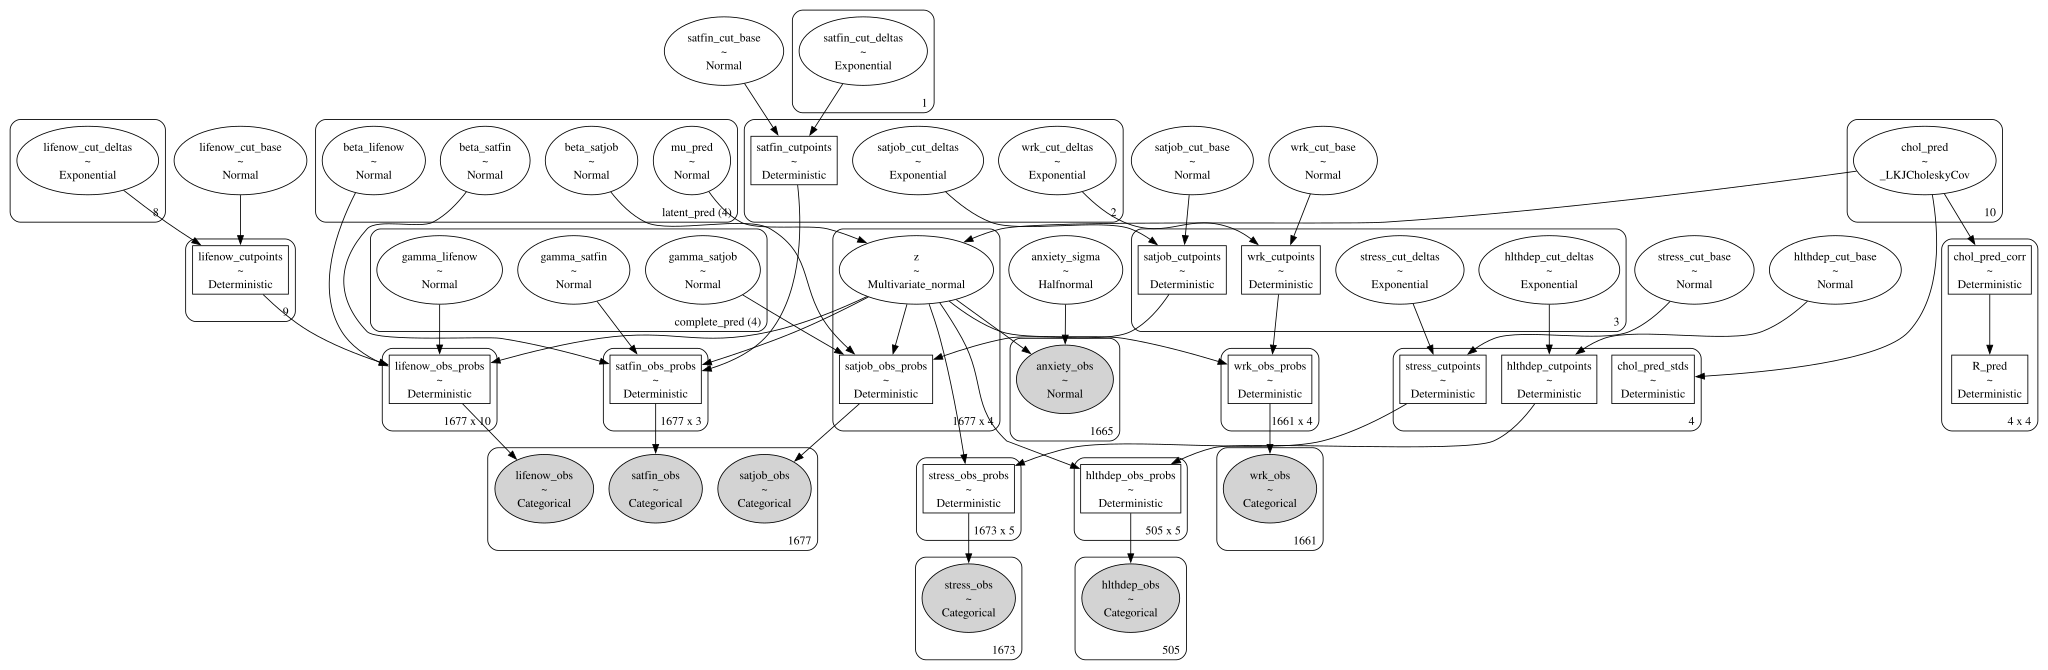

In [17]:
# Display model graph
pm.model_to_graphviz(marginal_imputation_model)

## Sampling

In [18]:
with marginal_imputation_model:
    trace = pm.sample(
        draws=1000,
        tune=1000,
        target_accept=0.95,
        nuts_sampler='nutpie',
        random_seed=42
    )

Progress,Draws,Divergences,Step Size,Gradients/Draw
,2000,0,0.04,255
,2000,0,0.07,63
,2000,0,0.06,511
,2000,0,0.08,63


## Convergence Diagnostics

In [19]:
# Check for divergences
print('=== SAMPLING DIAGNOSTICS ===')
if 'diverging' in trace.sample_stats:
    n_div = int(trace.sample_stats['diverging'].sum().values)
    print(f'Divergent transitions: {n_div}')
else:
    print('Divergence info not available')

=== SAMPLING DIAGNOSTICS ===
Divergent transitions: 0


In [20]:
# Summary of key parameters (excluding latent z)
key_vars = [
    'mu_pred', 'R_pred',
    'beta_lifenow', 'gamma_lifenow',
    'beta_satjob', 'gamma_satjob',
    'beta_satfin', 'gamma_satfin',
    'anxiety_sigma'
]

summary = az.summary(trace, var_names=key_vars)
print('=== PARAMETER SUMMARY ===')
print(summary[['mean', 'sd', 'hdi_3%', 'hdi_97%', 'r_hat', 'ess_bulk']])

/var/home/fonnesbeck/repos/Koenigsberg_Bayes/.pixi/envs/default/lib/python3.13/site-packages/arviz/stats/diagnostics.py:596: RuntimeWarning:

invalid value encountered in scalar divide

/var/home/fonnesbeck/repos/Koenigsberg_Bayes/.pixi/envs/default/lib/python3.13/site-packages/arviz/stats/diagnostics.py:991: RuntimeWarning:

invalid value encountered in scalar divide



=== PARAMETER SUMMARY ===
                           mean     sd  hdi_3%  hdi_97%  r_hat  ess_bulk
mu_pred[hlthdep]         -0.514  0.722  -1.665    0.719   1.99       5.0
mu_pred[stress]           0.410  0.542  -0.293    1.522   1.54       7.0
mu_pred[wrkmeangfl]       0.503  0.719  -0.770    1.835   2.09       5.0
mu_pred[anxiety]          0.002  0.024  -0.042    0.049   1.00    4203.0
R_pred[0, 0]              1.000  0.000   1.000    1.000    NaN    4000.0
R_pred[0, 1]             -0.676  0.121  -0.889   -0.440   1.37       9.0
R_pred[0, 2]              0.356  0.072   0.226    0.495   1.13      22.0
R_pred[0, 3]              0.747  0.054   0.638    0.852   1.17      17.0
R_pred[1, 0]             -0.676  0.121  -0.889   -0.440   1.37       9.0
R_pred[1, 1]              1.000  0.000   1.000    1.000   1.00    3604.0
R_pred[1, 2]             -0.390  0.145  -0.672   -0.173   1.64       7.0
R_pred[1, 3]             -0.657  0.114  -0.874   -0.432   1.60       7.0
R_pred[2, 0]             

In [21]:
# Check R-hat values for convergence
rhat_check = az.rhat(trace, var_names=key_vars)
rhat_vals = []
for v in key_vars:
    if v in rhat_check:
        vals = rhat_check[v].values.flatten()
        rhat_vals.extend(vals[~np.isnan(vals)])

if rhat_vals:
    max_rhat = max(rhat_vals)
    print(f'R-hat range: [{min(rhat_vals):.3f}, {max_rhat:.3f}]')
    if max_rhat < 1.01:
        print('Convergence looks good (R-hat < 1.01)')
    else:
        print('WARNING: Some parameters may not have converged (R-hat > 1.01)')

R-hat range: [1.000, 2.091]


/var/home/fonnesbeck/repos/Koenigsberg_Bayes/.pixi/envs/default/lib/python3.13/site-packages/arviz/stats/diagnostics.py:596: RuntimeWarning:

invalid value encountered in scalar divide



## Results: Predictor Correlation Matrix

In [22]:
# Extract predictor correlation matrix
R_pred_samples = trace.posterior['R_pred'].values.reshape(-1, 4, 4)
R_pred_mean = R_pred_samples.mean(axis=0)

R_pred_df = pd.DataFrame(R_pred_mean, index=latent_pred_names, columns=latent_pred_names)

print('=== PREDICTOR CORRELATION MATRIX (Posterior Mean) ===')
print(R_pred_df.round(3))

=== PREDICTOR CORRELATION MATRIX (Posterior Mean) ===
            hlthdep  stress  wrkmeangfl  anxiety
hlthdep       1.000  -0.676       0.356    0.747
stress       -0.676   1.000      -0.390   -0.657
wrkmeangfl    0.356  -0.390       1.000    0.182
anxiety       0.747  -0.657       0.182    1.000


In [23]:
# Visualize predictor correlations with heatmap
fig = go.Figure(data=go.Heatmap(
    z=R_pred_mean,
    x=latent_pred_names,
    y=latent_pred_names,
    colorscale='RdBu_r',
    zmin=-1, zmax=1,
    text=np.round(R_pred_mean, 2),
    texttemplate='%{text}',
    textfont={'size': 14}
))
fig.update_layout(
    title='Predictor Latent Correlation Matrix (Posterior Mean)',
    width=500, height=450
)
fig.show()

In [24]:
# Pairwise predictor correlations with uncertainty
print('=== PAIRWISE PREDICTOR CORRELATIONS WITH 94% HDI ===')
pairs = [
    (0, 1, 'hlthdep-stress'),
    (0, 2, 'hlthdep-wrkmeangfl'),
    (0, 3, 'hlthdep-anxiety'),
    (1, 2, 'stress-wrkmeangfl'),
    (1, 3, 'stress-anxiety'),
    (2, 3, 'wrkmeangfl-anxiety')
]

for i, j, name in pairs:
    rho = R_pred_samples[:, i, j]
    print(f'{name:20s}: {rho.mean():.3f} [{np.percentile(rho, 3):.3f}, {np.percentile(rho, 97):.3f}]')

=== PAIRWISE PREDICTOR CORRELATIONS WITH 94% HDI ===
hlthdep-stress      : -0.676 [-0.866, -0.395]
hlthdep-wrkmeangfl  : 0.356 [0.223, 0.494]
hlthdep-anxiety     : 0.747 [0.640, 0.856]
stress-wrkmeangfl   : -0.390 [-0.681, -0.181]
stress-anxiety      : -0.657 [-0.864, -0.420]
wrkmeangfl-anxiety  : 0.182 [0.114, 0.264]


## Results: Outcome Coefficients

In [25]:
# Extract coefficients for latent predictors
beta_lifenow_samples = trace.posterior['beta_lifenow'].values.reshape(-1, 4)
beta_satjob_samples = trace.posterior['beta_satjob'].values.reshape(-1, 4)
beta_satfin_samples = trace.posterior['beta_satfin'].values.reshape(-1, 4)

# Extract coefficients for complete predictors
gamma_lifenow_samples = trace.posterior['gamma_lifenow'].values.reshape(-1, 4)
gamma_satjob_samples = trace.posterior['gamma_satjob'].values.reshape(-1, 4)
gamma_satfin_samples = trace.posterior['gamma_satfin'].values.reshape(-1, 4)

In [38]:
# Combine all predictor coefficients for easier processing
all_predictor_names = latent_pred_names + complete_predictor_names

# Stack coefficients: latent (beta) then complete (gamma) for each outcome
coef_lifenow = np.hstack([beta_lifenow_samples, gamma_lifenow_samples])
coef_satjob = np.hstack([beta_satjob_samples, gamma_satjob_samples])
coef_satfin = np.hstack([beta_satfin_samples, gamma_satfin_samples])

# Print coefficients for all outcomes
def print_coefficients(name, coef_samples, predictor_names):
    """Print coefficients with 94% HDI"""
    print(f'=== {name} Coefficients ===')
    for i, pred_name in enumerate(predictor_names):
        c = coef_samples[:, i]
        print(f'  {pred_name:12s}: {c.mean():7.3f} [{np.percentile(c, 3):7.3f}, {np.percentile(c, 97):7.3f}]')
    print()

print_coefficients('LIFENOW', coef_lifenow, all_predictor_names)
print_coefficients('SATJOB', coef_satjob, all_predictor_names)
print_coefficients('SATFIN', coef_satfin, all_predictor_names)

=== LIFENOW Coefficients ===
  hlthdep     :  -1.508 [ -2.251,  -0.844]
  stress      :  -0.101 [ -1.306,   0.852]
  wrkmeangfl  :  -0.103 [ -0.470,   0.187]
  anxiety     :   0.647 [  0.136,   1.279]
  age         :   0.187 [  0.078,   0.293]
  female      :   0.083 [ -0.123,   0.283]
  degree      :   0.187 [  0.074,   0.304]
  finrela     :   0.507 [  0.393,   0.630]

=== SATJOB Coefficients ===
  hlthdep     :   0.463 [ -0.001,   0.912]
  stress      :  -1.544 [ -3.044,   0.058]
  wrkmeangfl  :   1.585 [  0.709,   3.465]
  anxiety     :  -0.853 [ -1.483,  -0.244]
  age         :  -0.217 [ -0.371,  -0.073]
  female      :   0.249 [ -0.032,   0.537]
  degree      :   0.108 [ -0.045,   0.265]
  finrela     :  -0.213 [ -0.369,  -0.064]

=== SATFIN Coefficients ===
  hlthdep     :   1.203 [  0.662,   1.857]
  stress      :  -0.115 [ -1.156,   1.127]
  wrkmeangfl  :  -0.056 [ -0.336,   0.310]
  anxiety     :  -0.731 [ -1.367,  -0.262]
  age         :  -0.077 [ -0.185,   0.030]
  female  

In [39]:
# Combined forest plot: ALL predictor effects across outcomes
fig = make_subplots(
    rows=1, cols=3,
    subplot_titles=['LIFENOW', 'SATJOB', 'SATFIN'],
    shared_yaxes=True
)

colors = ['blue', 'red', 'green']
coef_data = [coef_lifenow, coef_satjob, coef_satfin]

for col, (coef_samples, color) in enumerate(zip(coef_data, colors), 1):
    for i, name in enumerate(all_predictor_names):
        mean_val = coef_samples[:, i].mean()
        hdi_low = np.percentile(coef_samples[:, i], 3)
        hdi_high = np.percentile(coef_samples[:, i], 97)

        fig.add_trace(go.Scatter(
            x=[mean_val], y=[name],
            mode='markers',
            marker=dict(size=10, color=color),
            error_x=dict(
                type='data',
                array=[hdi_high - mean_val],
                arrayminus=[mean_val - hdi_low]
            ),
            showlegend=False
        ), row=1, col=col)

    fig.add_vline(x=0, line_dash='dash', line_color='gray', row=1, col=col)

fig.update_layout(
    title='Outcome Coefficients (94% HDI)',
    height=500, width=1100
)
for col in range(1, 4):
    fig.update_xaxes(title_text='Coefficient', row=1, col=col)
fig.show()

In [40]:
# Coefficient comparison table
comparison_data = pd.DataFrame({
    'Predictor': all_predictor_names,
    'LIFENOW': [f"{coef_lifenow[:, i].mean():+.3f}" for i in range(len(all_predictor_names))],
    'SATJOB': [f"{coef_satjob[:, i].mean():+.3f}" for i in range(len(all_predictor_names))],
    'SATFIN': [f"{coef_satfin[:, i].mean():+.3f}" for i in range(len(all_predictor_names))],
})

print('=== COEFFICIENT COMPARISON (Posterior Means) ===')
print('Note: Higher outcome values = more dissatisfied')
print()
print(comparison_data.to_string(index=False))

=== COEFFICIENT COMPARISON (Posterior Means) ===
Note: Higher outcome values = more dissatisfied

 Predictor LIFENOW SATJOB SATFIN
   hlthdep  -1.508 +0.463 +1.203
    stress  -0.101 -1.544 -0.115
wrkmeangfl  -0.103 +1.585 -0.056
   anxiety  +0.647 -0.853 -0.731
       age  +0.187 -0.217 -0.077
    female  +0.083 +0.249 +0.094
    degree  +0.187 +0.108 -0.238
   finrela  +0.507 -0.213 -1.010


## Results: Imputed Values

In [32]:
# Extract posterior distribution of latent z values
z_samples = trace.posterior['z'].values.reshape(-1, N, 4)
z_mean = z_samples.mean(axis=0)  # (N, 4) posterior means
z_std = z_samples.std(axis=0)    # (N, 4) posterior std devs

print(f'Latent z shape: {z_mean.shape}')
print(f'  Rows = observations, Columns = [hlthdep, stress, wrkmeangfl, anxiety]')

Latent z shape: (1677, 4)
  Rows = observations, Columns = [hlthdep, stress, wrkmeangfl, anxiety]


In [33]:
# Compare latent z distributions: observed vs imputed
fig = make_subplots(rows=2, cols=2, subplot_titles=latent_pred_names)

obs_indices = [hlthdep_obs_idx, stress_obs_idx, wrk_obs_idx, anxiety_obs_idx]
miss_indices = [hlthdep_miss_idx, stress_miss_idx, wrk_miss_idx, anxiety_miss_idx]

for idx, (name, obs_idx, miss_idx) in enumerate(zip(latent_pred_names, obs_indices, miss_indices)):
    row = idx // 2 + 1
    col = idx % 2 + 1
    
    # Latent values for observed cases
    z_obs = z_mean[obs_idx, idx]
    # Latent values for missing cases (imputed)
    z_imp = z_mean[miss_idx, idx] if len(miss_idx) > 0 else np.array([])
    
    fig.add_trace(
        go.Histogram(x=z_obs, name='Observed', opacity=0.7, 
                     marker_color='blue', nbinsx=30,
                     showlegend=(idx == 0)),
        row=row, col=col
    )
    if len(z_imp) > 0:
        fig.add_trace(
            go.Histogram(x=z_imp, name='Imputed', opacity=0.7,
                         marker_color='red', nbinsx=30,
                         showlegend=(idx == 0)),
            row=row, col=col
        )

fig.update_layout(
    title='Latent Predictor Distributions: Observed vs Imputed',
    height=600, width=900,
    barmode='overlay'
)
fig.show()

In [34]:
# Summary statistics for imputed values
print('=== IMPUTED LATENT VALUES SUMMARY ===')
for i, (name, obs_idx, miss_idx) in enumerate(zip(latent_pred_names, obs_indices, miss_indices)):
    z_obs = z_mean[obs_idx, i]
    z_imp = z_mean[miss_idx, i] if len(miss_idx) > 0 else np.array([])
    
    print(f'\n{name}:')
    print(f'  Observed (n={len(obs_idx)}): mean={z_obs.mean():.3f}, std={z_obs.std():.3f}')
    if len(z_imp) > 0:
        z_imp_std = z_std[miss_idx, i]
        print(f'  Imputed  (n={len(miss_idx)}): mean={z_imp.mean():.3f}, std={z_imp.std():.3f}')
        print(f'  Imputation uncertainty: mean posterior std = {z_imp_std.mean():.3f}')

=== IMPUTED LATENT VALUES SUMMARY ===

hlthdep:
  Observed (n=505): mean=-0.576, std=1.154
  Imputed  (n=1172): mean=-0.488, std=1.121
  Imputation uncertainty: mean posterior std = 1.017

stress:
  Observed (n=1673): mean=0.411, std=0.512
  Imputed  (n=4): mean=0.442, std=0.309
  Imputation uncertainty: mean posterior std = 0.781

wrkmeangfl:
  Observed (n=1661): mean=0.501, std=1.095
  Imputed  (n=16): mean=0.857, std=0.923
  Imputation uncertainty: mean posterior std = 1.277

anxiety:
  Observed (n=1665): mean=0.000, std=0.901
  Imputed  (n=12): mean=0.241, std=0.276
  Imputation uncertainty: mean posterior std = 0.819


In [35]:
# Imputation uncertainty visualization
# Show posterior uncertainty for imputed values
fig = make_subplots(rows=2, cols=2, subplot_titles=[
    f'{name} (n_imputed={len(miss_idx)})' 
    for name, miss_idx in zip(latent_pred_names, miss_indices)
])

for idx, (name, miss_idx) in enumerate(zip(latent_pred_names, miss_indices)):
    row = idx // 2 + 1
    col = idx % 2 + 1
    
    if len(miss_idx) > 0:
        z_imp_std = z_std[miss_idx, idx]
        fig.add_trace(
            go.Histogram(x=z_imp_std, nbinsx=30, 
                         marker_color='orange', showlegend=False),
            row=row, col=col
        )
        fig.update_xaxes(title_text='Posterior Std Dev', row=row, col=col)

fig.update_layout(
    title='Imputation Uncertainty: Posterior Std Dev of Imputed z Values',
    height=500, width=800
)
fig.show()

## Summary

In [ ]:
print('=' * 70)
print('THREE MARGINAL ORDINAL REGRESSIONS WITH SHARED IMPUTATION')
print('=' * 70)

print(f'\n1. MODEL SUMMARY')
print(f'   Sample size: {N}')
print(f'   Outcomes: LIFENOW (1-10), SATJOB (1-4), SATFIN (1-3)')
print(f'   Imputed predictors: hlthdep, stress, wrkmeangfl, anxiety')
print(f'   Complete predictors: age, female, degree, finrela')
print(f'   Model type: Three marginal (independent) ordinal regressions')
print(f'               with shared latent predictor imputation')

print(f'\n2. CONVERGENCE')
if 'diverging' in trace.sample_stats:
    n_div = int(trace.sample_stats['diverging'].sum().values)
    print(f'   Divergent transitions: {n_div}')
if rhat_vals:
    print(f'   R-hat range: [{min(rhat_vals):.3f}, {max(rhat_vals):.3f}]')

print(f'\n3. PREDICTOR CORRELATIONS (Posterior Mean)')
print('   Latent correlation matrix (4x4):')
for i, row_name in enumerate(latent_pred_names):
    row_str = '   ' + row_name.ljust(12) + ': '
    row_str += ' '.join([f'{R_pred_mean[i, j]:6.3f}' for j in range(4)])
    print(row_str)

print(f'\n4. KEY FINDINGS')
print('   Outcome coding: higher values = more dissatisfied')
print()
print('   LIFENOW (Life Satisfaction):')
print(f'     - Depression (hlthdep): {coef_lifenow[:, 0].mean():.3f}')
print(f'     - Anxiety: {coef_lifenow[:, 3].mean():.3f}')
print(f'     - Financial status (finrela): {coef_lifenow[:, 7].mean():.3f}')
print()
print('   SATJOB (Job Satisfaction):')
print(f'     - Work stress: {coef_satjob[:, 1].mean():.3f}')
print(f'     - Work meaningfulness: {coef_satjob[:, 2].mean():.3f}')
print(f'     - Age: {coef_satjob[:, 4].mean():.3f}')
print()
print('   SATFIN (Financial Satisfaction):')
print(f'     - Depression (hlthdep): {coef_satfin[:, 0].mean():.3f}')
print(f'     - Financial status (finrela): {coef_satfin[:, 7].mean():.3f}')
print(f'     - Degree: {coef_satfin[:, 6].mean():.3f}')

print(f'\n5. ADVANTAGES OF THIS APPROACH')
print('   - Simpler than joint outcome model (no residual correlations)')
print('   - Better sampling geometry (marginal likelihoods)')
print('   - Larger effective sample size (uses partial data via imputation)')
print('   - Interpretable coefficients (same as standard ordinal regression)')

In [37]:
# Save trace
az.to_netcdf(trace, 'trivariate_imputation_trace.nc')
print('Trace saved to trivariate_imputation_trace.nc')

Trace saved to trivariate_imputation_trace.nc
